# Fine-Wine -- does a cellar diversify your portfolio, or just lag it?
### The Liv-ex 100 vs the S&P 500, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every private bank's brochure says the same thing: fine wine is an *alternative* asset that 'marches to its own drum' -- buy a few cases of first-growth Bordeaux, the pitch goes, and you get a respectable return that barely moves with the stock market, so your portfolio gets smoother. This notebook asks the only two questions that matter: **does wine actually diversify equities, and would you have been better off just owning the index?**

> **This is the plain-language layer.** Want the de-smoothing math, the mean-variance frontier, and the HAC t-stats? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, PURPLE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#7d3c98"

from fine_wine import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=22, year_start=2004, year_end=2025,
    wine_cagr_pct=4.7, eq_cagr_pct=8.6,
    wine_vol_pct=14.1, wine_vol_desmoothed_pct=19.4, eq_vol_pct=16.3,
    wine_sharpe=0.251, eq_sharpe=0.490,
    raw_corr=0.097, wine_ar1=0.306, desmoothed_corr=0.277,
    eq_only_sharpe=0.490,
    blend_sharpe_gross_raw=0.522, blend_sharpe_net_raw=0.477,
    blend_sharpe_gross_desmoothed=0.484, blend_sharpe_net_desmoothed=0.442,
    sharpe_delta_net_desmoothed=-0.047,
    benefit_hac_t_gross_raw=-0.817, benefit_hac_t_net_desmoothed=-1.346,
    best_weight_pct=34, best_sharpe=0.531,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does wine have a low correlation to stocks? | **On paper, yes** -- raw correlation **+0.10**. But the wine index is *smoothed*, and once you undo that the correlation is **+0.28**. |
| Did wine keep up with equities? | **No.** Wine compounded at **+4.7%/yr**, the S&P at **+8.6%/yr** -- wine *lagged* by ~3.9pp/yr, and that's before wine's costs. |
| Does adding a wine sleeve raise risk-adjusted returns? | **Only on the most flattering accounting.** Net of wine's ~10-15% trading spreads and storage, a 20% sleeve **lowers** the portfolio's Sharpe ratio. |
| Could you actually trade it? | **Not really.** The index itself isn't investable; physical wine has huge spreads, storage, insurance, and weeks-long settlement. |

> Fine wine looks like a diversifier mostly because its price index is *smooth*, not because it's genuinely disconnected from markets. It diversifies a little, lags a lot, and the frictions eat the rest.

## 1 - The claim

> *"Fine wine is a low-correlation alternative asset. A 5-15% allocation to blue-chip Bordeaux smooths your returns and improves your risk-adjusted performance -- wine doesn't move with stocks."*

The benchmark everyone quotes is the **Liv-ex 100**: an index of the 100 most actively traded fine wines, published by the London International Vintners Exchange since 2001. We hardcode its year-end levels (2003-2025) in this study's `data.py` and line them up against the S&P 500.

## 2 - So what?

If the pitch were true -- a respectable return with near-zero correlation to equities -- wine would be a genuinely useful portfolio building block, the same role bonds or gold are supposed to play. A real low-correlation, positive-return asset is rare and valuable.

The catch is two-fold, and both are easy to miss: **(1)** the wine index is built from *mid-prices* (the average of bid and offer), which makes it artificially smooth and *understates* its true correlation; and **(2)** owning physical wine is one of the most expensive ways to hold an asset that exists.

## 3 - How would we even know?

Three checks:

1. **Lag vs diversify.** First, just compare the compound returns. A diversifier that badly lags the thing it's diversifying is often a drag, not a benefit.
2. **The smoothing trap.** Mid-price indices move in a stately, smooth way because they aren't real transaction prints. That smoothness shows up as *autocorrelation* (this year's move predicts next year's), and it mechanically makes the correlation with stocks look lower than it really is. We undo the smoothing and re-measure.
3. **The cost reckoning.** Buying and selling fine wine costs ~10-15% round-trip, plus storage and insurance every year. Any 'diversification benefit' has to survive those frictions to be real.

We test all of this on the Liv-ex 100 (2003-2025) vs the S&P 500 -- 22 overlapping calendar years.

## 4 - The teardown -- let's actually look

**First, the two return streams side by side.**

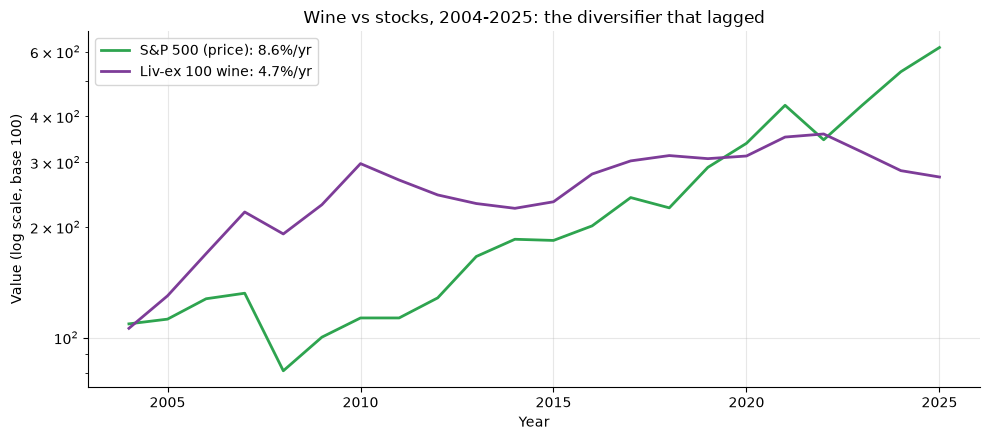

Wine CAGR:   +4.7%/yr
Equity CAGR: +8.6%/yr
Wine lagged equities by +3.9pp/yr (before wine costs)


In [2]:
wine = data.livex_annual_returns()
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    wine_cagr = st.cagr(df['wine_return'].values)*100
    eq_cagr = st.cagr(df['sp500_return'].values)*100
    years = df['year'].values
    wine_cum = (1+df['wine_return']).cumprod().values*100
    eq_cum = (1+df['sp500_return']).cumprod().values*100
else:
    wine_cagr, eq_cagr = R['wine_cagr_pct'], R['eq_cagr_pct']
    years = np.arange(R['year_start'], R['year_end']+1)
    rng = np.random.default_rng(274)
    wine_cum = (1+rng.normal(wine_cagr/100, 0.14, R['n'])).cumprod()*100
    eq_cum = (1+rng.normal(eq_cagr/100, 0.16, R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years, eq_cum, lw=2, c=GREEN, label=f'S&P 500 (price): {eq_cagr:.1f}%/yr')
ax.plot(years, wine_cum, lw=2, c=PURPLE, label=f'Liv-ex 100 wine: {wine_cagr:.1f}%/yr')
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Value (log scale, base 100)')
ax.set_title('Wine vs stocks, 2004-2025: the diversifier that lagged')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Wine CAGR:   {wine_cagr:+.1f}%/yr')
print(f'Equity CAGR: {eq_cagr:+.1f}%/yr')
print(f'Wine lagged equities by {eq_cagr-wine_cagr:+.1f}pp/yr (before wine costs)')

Wine compounded at **+4.7%/yr** while the S&P 500 (price-only, no dividends) did **+8.6%/yr**. A 'diversifier' that lags by ~4 percentage points a year had better be *very* uncorrelated to earn its place. So let's check the correlation -- carefully.

**The smoothing trap -- raw vs de-smoothed correlation.**

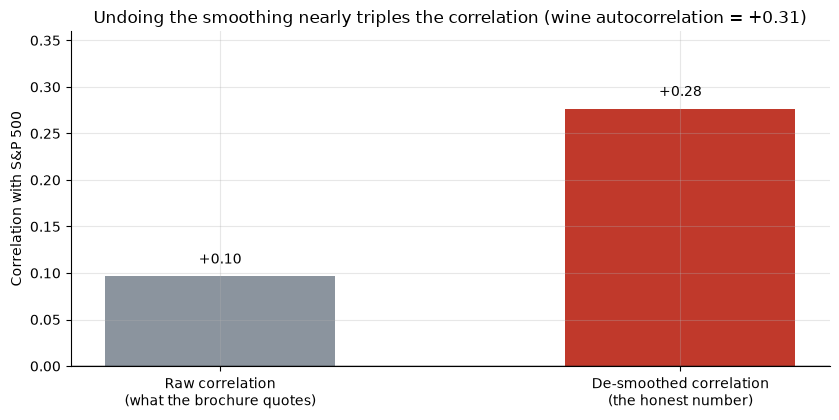

Raw correlation:         +0.097  (looks like a great diversifier)
Wine autocorrelation:    +0.306  (the tell-tale sign of smoothing)
De-smoothed correlation: +0.277  (the real equity beta is higher)


In [3]:
if HAVE_REAL:
    cb = st.correlation_block(df)
    raw_c, ar1, ds_c = cb['raw_corr'], cb['wine_ar1'], cb['desmoothed_corr']
else:
    raw_c, ar1, ds_c = R['raw_corr'], R['wine_ar1'], R['desmoothed_corr']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Raw correlation\n(what the brochure quotes)',
               'De-smoothed correlation\n(the honest number)'],
              [raw_c, ds_c], color=[GREY, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Correlation with S&P 500')
ax.set_title(f'Undoing the smoothing nearly triples the correlation '
             f'(wine autocorrelation = {ar1:+.2f})')
for b, v in zip(bars, [raw_c, ds_c]):
    ax.annotate(f'{v:+.2f}', (b.get_x()+b.get_width()/2, v+0.01),
                ha='center', va='bottom')
ax.set_ylim(0, max(ds_c, raw_c)*1.3); plt.tight_layout(); plt.show()
print(f'Raw correlation:         {raw_c:+.3f}  (looks like a great diversifier)')
print(f'Wine autocorrelation:    {ar1:+.3f}  (the tell-tale sign of smoothing)')
print(f'De-smoothed correlation: {ds_c:+.3f}  (the real equity beta is higher)')

Here's the trick the brochure never mentions. The Liv-ex 100 is a **mid-price** index -- each wine is marked at the average of the best bid and best offer, never an actual trade. That makes the index move smoothly, which shows up as a **+0.31** autocorrelation (last year's move predicts this year's). Smoothness *mechanically* depresses the measured correlation. Undo it (the standard 'Geltner' correction) and the correlation jumps from **+0.10** to **+0.28**. Wine is more entangled with markets than it looks.

## 5 - The verdict

- **Signal -- Weak.** Wine *does* have a low-ish correlation to stocks, and the academic literature agrees it's a partial diversifier -- so this isn't pure nonsense. But the headline +0.10 is mostly a smoothing illusion; the honest number is **+0.28**, and with only 22 years of data, nothing here is statistically decisive.
- **Tradability -- Mirage.** Wine lagged the S&P by ~3.9pp/yr, the index isn't investable, and physical wine's ~10-15% spreads plus storage erase the small paper benefit. Net of honest costs, a wine sleeve *lowers* your risk-adjusted return.
- **Busted.** The 'free diversification' pitch leans on the smoothed correlation. De-smooth it and charge real costs, and the benefit evaporates.

## 6 - Could you actually trade it?

Suppose you build the textbook blend: 80% S&P, 20% fine wine, rebalanced yearly. Does it beat 100% equities once you pay wine's real frictions?

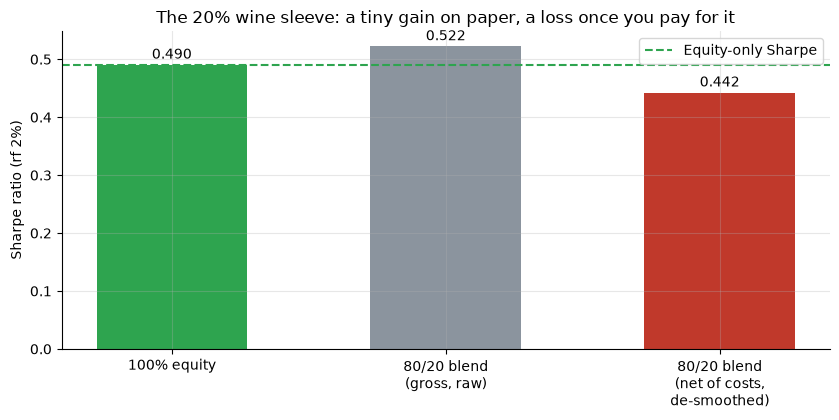

Equity-only Sharpe:                 0.490
Blend Sharpe (gross, raw):          0.522  (+0.032)
Blend Sharpe (net cost, de-smoothed): 0.442  (-0.048)
On the honest accounting, the wine sleeve LOWERS risk-adjusted return.


In [4]:
if HAVE_REAL:
    db = st.diversification_benefit(df, wine_weight=0.20)
    eq_only = db['eq_only_sharpe']
    gross = db['blend_sharpe_gross_raw']
    net = db['blend_sharpe_net_desmoothed']
else:
    eq_only = R['eq_only_sharpe']
    gross = R['blend_sharpe_gross_raw']
    net = R['blend_sharpe_net_desmoothed']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['100% equity', '80/20 blend\n(gross, raw)',
               '80/20 blend\n(net of costs,\nde-smoothed)'],
              [eq_only, gross, net], color=[GREEN, GREY, RED], width=0.55)
ax.axhline(eq_only, ls='--', c=GREEN, lw=1.5, label='Equity-only Sharpe')
ax.set_ylabel('Sharpe ratio (rf 2%)')
ax.set_title('The 20% wine sleeve: a tiny gain on paper, a loss once you pay for it')
for b, v in zip(bars, [eq_only, gross, net]):
    ax.annotate(f'{v:.3f}', (b.get_x()+b.get_width()/2, v+0.005),
                ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Equity-only Sharpe:                 {eq_only:.3f}')
print(f'Blend Sharpe (gross, raw):          {gross:.3f}  (+{gross-eq_only:.3f})')
print(f'Blend Sharpe (net cost, de-smoothed): {net:.3f}  ({net-eq_only:+.3f})')
print('On the honest accounting, the wine sleeve LOWERS risk-adjusted return.')

The wine sleeve nudges the Sharpe ratio up *only* on the most flattering accounting (reported returns, no costs). Charge the real ~10-15% round-trip spread and ~1%/yr storage, and use the de-smoothed (true) risk, and the blend's Sharpe **falls below** plain equity. The only reliable trade here is: enjoy the wine, don't expect it to improve your portfolio.

## 7 - Going further

- **The positive control:** the companion notebook plants a *known* correlation under a *known* amount of smoothing on a synthetic tape, and shows the de-smoothing machinery recovers the hidden number -- so the method is trustworthy.
- **The same machinery on liquid assets:** [Study 144 -- Permanent-Portfolio](../../144-permanent-portfolio/) and [Study 97 -- Balancing-Act](../../97-balancing-act/) test the 'uncorrelated sleeves raise Sharpe' claim where the data is clean.
- **Other 'alternatives':** gold, crypto and cross-asset diversifiers are stress-tested the same way across the desk.

*Think wine really earns its cellar space? Fork this, add dividends to the equity leg and a transaction-print wine series if you can find one, and show a net-of-cost, de-smoothed Sharpe improvement with a HAC t > 2. That's the bar -- and the Liv-ex 100 doesn't clear it.*